# JPEG-LS Stage 1 Bring-Up Notebook

This notebook is a **Stage-1 software bring-up notebook** for the `jpeg-project`.

The goal here is not to finish the full FPGA IP yet.  
The goal is to first build a clean Python-side flow that covers:

1. **Step 1** — define the `.mem` input format and compressed bitstream output format  
2. **Step 2** — build two simple Python tools:
   - `image_to_mem.py`
   - `synth_image.py`
3. **Step 3** — build a first `jpegls_regular.py` reference encoder that supports:
   - `uint8`
   - lossless
   - regular mode only
   - small image tests

This notebook defines the problem, specifies the file formats, builds a Python golden reference, and generates test vectors for later HLS/RTL use.


## Problem Formulation

The project target is a **lossless grayscale JPEG-LS regular-mode encoder**.

For the current stage, we intentionally keep the scope small:

- **8-bit grayscale only**
- **encoder only**
- **lossless only**
- **regular mode only**
- **small-image verification first**

For each pixel `X` in raster order, the encoder uses the causal neighborhood:

```text
C  B  D
A  X
```

and then performs the regular-mode steps:

1. compute local gradients
2. quantize context
3. run the median edge detector predictor
4. compute prediction residual
5. map the signed residual to a nonnegative integer
6. encode with a Golomb-style code
7. pack bits into output bytes

This notebook gives a **clean stage-1 reference path** for software validation and later HLS bring-up.


## Step 1 — Define the file formats first

Before writing any encoder logic, we lock down two practical formats.

### A. Raw grayscale input `.mem`

For the first stage, we use a simple convention:

- image dtype: `uint8`
- shape: `(height, width)`
- scan order: **row-major** / raster scan
- `.mem` contents: **one pixel per line**
- default text format: **two-digit uppercase hex**
- no binary header inside the `.mem` itself

Example:

```text
00
7F
FF
10
22
...
```

Dimensions can be stored separately in a small text file such as:

```text
HEIGHT WIDTH
```

or inside comment lines if desired.

### B. Compressed output format

The encoder produces a **variable-length bitstream**, so we define a small software-side bit packing rule:

- append bits **MSB-first**
- flush into bytes
- final partial byte is **zero-padded on the right**
- saved compressed `.mem` uses **one byte per line in hex**

Example compressed `.mem`:

```text
A6
1C
00
F3
...
```

This is simple enough for Python, and later very easy to mirror in RTL/HLS testbenches.


## Suggested project layout

```text
jpeg_stage1/
├── stage1_jpegls_notebook.ipynb
├── python_ref/
│   ├── image_to_mem.py
│   ├── synth_image.py
│   └── jpegls_regular.py
└── data/
    ├── input.mem
    ├── dims.txt
    ├── compressed.mem
    └── trace_*.npy / trace_*.csv
```

The notebook below will generate the three Python files into `python_ref/`.


In [36]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

root_dir = Path.cwd()
pyref_dir = root_dir / "python_ref"
data_dir = root_dir / "data"

pyref_dir.mkdir(exist_ok=True)
data_dir.mkdir(exist_ok=True)

print("root_dir   =", root_dir)
print("pyref_dir  =", pyref_dir)
print("data_dir   =", data_dir)


root_dir   = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls
pyref_dir  = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/python_ref
data_dir   = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data


## Step 2A — Build `image_to_mem.py`

This file handles:

- reading a real image
- converting it to 8-bit grayscale
- exporting it to `.mem`
- optionally writing a `dims.txt` helper file


In [37]:
image_to_mem_code = r'''from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
from PIL import Image


def load_image_as_grayscale(path: str | Path) -> np.ndarray:
    """
    Load an image file and return a uint8 grayscale array with shape (H, W).
    """
    img = Image.open(path).convert("L")
    arr = np.asarray(img, dtype=np.uint8)
    if arr.ndim != 2:
        raise ValueError(f"Expected a grayscale 2-D array, got shape={arr.shape}")
    return arr


def save_mem(
    image: np.ndarray,
    mem_path: str | Path,
    *,
    fmt: str = "hex",
    include_dims_header: bool = False,
) -> None:
    """
    Save a uint8 grayscale image to a .mem file in row-major order.

    By default:
      - one pixel per line
      - two-digit uppercase hexadecimal
      - no header

    Example:
      00
      7F
      FF
    """
    arr = np.asarray(image)
    if arr.ndim != 2:
        raise ValueError(f"Expected shape (H, W), got {arr.shape}")
    if arr.dtype != np.uint8:
        raise TypeError(f"Expected dtype uint8, got {arr.dtype}")

    mem_path = Path(mem_path)
    lines: list[str] = []

    if include_dims_header:
        h, w = arr.shape
        lines.append(f"// HEIGHT={h}")
        lines.append(f"// WIDTH={w}")

    flat = arr.reshape(-1)
    if fmt == "hex":
        lines.extend(f"{int(v):02X}" for v in flat)
    elif fmt == "bin":
        lines.extend(f"{int(v):08b}" for v in flat)
    else:
        raise ValueError("fmt must be 'hex' or 'bin'")

    mem_path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def load_mem(
    mem_path: str | Path,
    *,
    height: int,
    width: int,
    fmt: str = "hex",
) -> np.ndarray:
    """
    Load a .mem file back into a uint8 image of shape (height, width).
    Comment lines starting with // are ignored.
    """
    mem_path = Path(mem_path)
    values: list[int] = []
    for raw in mem_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("//"):
            continue
        if fmt == "hex":
            values.append(int(line, 16))
        elif fmt == "bin":
            values.append(int(line, 2))
        else:
            raise ValueError("fmt must be 'hex' or 'bin'")

    if len(values) != height * width:
        raise ValueError(
            f"Expected {height*width} pixels, found {len(values)} in {mem_path}"
        )

    return np.asarray(values, dtype=np.uint8).reshape(height, width)


def write_dims_file(image: np.ndarray, path: str | Path) -> None:
    arr = np.asarray(image)
    if arr.ndim != 2:
        raise ValueError(f"Expected shape (H, W), got {arr.shape}")
    h, w = arr.shape
    Path(path).write_text(f"{h} {w}\n", encoding="utf-8")


def _build_argparser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(
        description="Convert an image to an 8-bit grayscale .mem file."
    )
    parser.add_argument("--input", required=True, help="Input image path")
    parser.add_argument("--output", required=True, help="Output .mem path")
    parser.add_argument(
        "--fmt",
        default="hex",
        choices=["hex", "bin"],
        help="Pixel format written to the .mem file",
    )
    parser.add_argument(
        "--dims-out",
        default=None,
        help="Optional text file for writing 'HEIGHT WIDTH'",
    )
    parser.add_argument(
        "--include-dims-header",
        action="store_true",
        help="Include comment header lines in the .mem file",
    )
    return parser


def main() -> None:
    parser = _build_argparser()
    args = parser.parse_args()

    img = load_image_as_grayscale(args.input)
    save_mem(
        img,
        args.output,
        fmt=args.fmt,
        include_dims_header=args.include_dims_header,
    )

    if args.dims_out:
        write_dims_file(img, args.dims_out)

    print(f"Converted {args.input} -> {args.output}, shape={img.shape}")


if __name__ == "__main__":
    main()'''
(pyref_dir / "image_to_mem.py").write_text(image_to_mem_code + "\n", encoding="utf-8")
print("Wrote", pyref_dir / "image_to_mem.py")


Wrote /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/python_ref/image_to_mem.py


In [40]:
if str(pyref_dir) not in sys.path:
    sys.path.insert(0, str(pyref_dir))

from python_ref import image_to_mem

for name in ["two macaws", "whitewater rafting"]:
    img = image_to_mem.load_image_as_grayscale(root_dir / f"{name}.png")
    image_to_mem.save_mem(img, root_dir / f"{name}.mem")
    print(f"{name} shape:", img.shape)


two macaws shape: (512, 768)
whitewater rafting shape: (512, 768)


### Example terminal usage for `image_to_mem.py`

The commands below can be run in a terminal, or executed directly inside this notebook using a `%%bash` cell.


In [41]:
%%bash
uv run python python_ref/image_to_mem.py     --input "two macaws.png"     --output "two macaws.mem"

uv run python python_ref/image_to_mem.py     --input "whitewater rafting.png"     --output "whitewater rafting.mem"


Converted two macaws.png -> two macaws.mem, shape=(512, 768)
Converted whitewater rafting.png -> whitewater rafting.mem, shape=(512, 768)


## Step 2A.1 — Visual check for real images

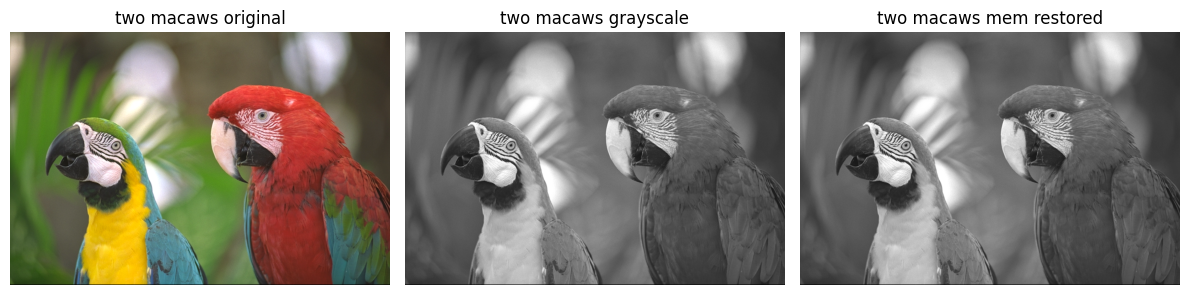

two macaws:
  original mode      = RGB
  grayscale shape    = (512, 768)
  mem path           = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/two macaws.mem
  gray png path      = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/two macaws_gray.png
  restored png path  = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/two macaws_restored.png
  gray == restored?  = True
  max abs diff       = 0

===== two macaws.mem (first 16 lines) =====
71
72
75
73
75
75
72
77
75
75
77
76
76
75
75
76



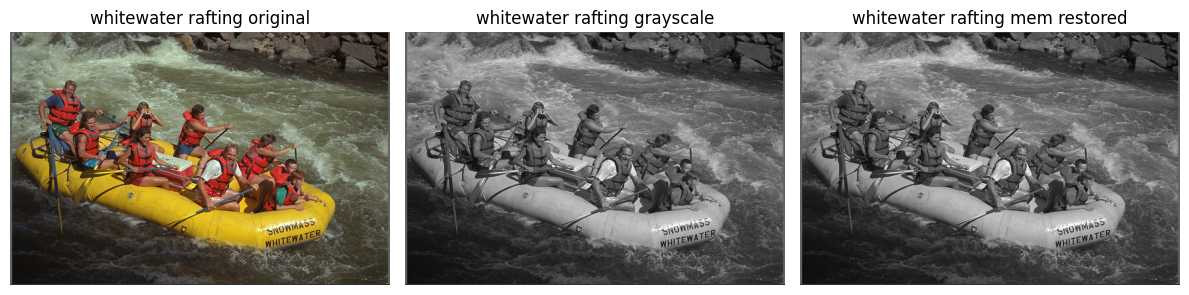

whitewater rafting:
  original mode      = RGB
  grayscale shape    = (512, 768)
  mem path           = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/whitewater rafting.mem
  gray png path      = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/whitewater rafting_gray.png
  restored png path  = /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/whitewater rafting_restored.png
  gray == restored?  = True
  max abs diff       = 0

===== whitewater rafting.mem (first 16 lines) =====
63
63
63
63
63
63
63
63
63
63
63
63
63
63
63
63



In [42]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from python_ref import image_to_mem

for name in ["two macaws", "whitewater rafting"]:
    img_path = root_dir / f"{name}.png"
    mem_path = root_dir / f"{name}.mem"
    gray_png_path = root_dir / f"{name}_gray.png"
    restored_png_path = root_dir / f"{name}_restored.png"

    # 1) Load the original image for display
    orig = Image.open(img_path)

    # 2) Convert the image to an 8-bit grayscale array
    gray = image_to_mem.load_image_as_grayscale(img_path)

    # 3) Save grayscale pixels to .mem
    image_to_mem.save_mem(gray, mem_path, fmt="hex", include_dims_header=False)

    # 4) Save the grayscale image as a PNG file
    Image.fromarray(gray, mode="L").save(gray_png_path)

    # 5) Load the image back from the .mem file
    restored = image_to_mem.load_mem(
        mem_path,
        height=gray.shape[0],
        width=gray.shape[1],
        fmt="hex",
    )

    # 6) Save the restored image as a PNG file
    Image.fromarray(restored, mode="L").save(restored_png_path)

    # 7) Check whether the grayscale image and restored image are identical
    same = np.array_equal(gray, restored)

    # 8) Compute the pixel-wise difference for verification
    diff = restored.astype(np.int16) - gray.astype(np.int16)
    max_abs_diff = np.max(np.abs(diff))

    # 9) Display the original image, grayscale image, and restored image
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    if orig.mode == "L":
        axes[0].imshow(orig, cmap="gray", vmin=0, vmax=255)
    else:
        axes[0].imshow(orig)
    axes[0].set_title(f"{name} original")
    axes[0].axis("off")

    axes[1].imshow(gray, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title(f"{name} grayscale")
    axes[1].axis("off")

    axes[2].imshow(restored, cmap="gray", vmin=0, vmax=255)
    axes[2].set_title(f"{name} mem restored")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    # 10) Print summary information
    print(f"{name}:")
    print("  original mode      =", orig.mode)
    print("  grayscale shape    =", gray.shape)
    print("  mem path           =", mem_path)
    print("  gray png path      =", gray_png_path)
    print("  restored png path  =", restored_png_path)
    print("  gray == restored?  =", same)
    print("  max abs diff       =", max_abs_diff)
    print()

    # 11) Print the first 16 lines of the .mem file
    print(f"===== {name}.mem (first 16 lines) =====")
    lines = mem_path.read_text(encoding="utf-8").splitlines()
    for line in lines[:16]:
        print(line)
    print()


## Step 2B — Build `synth_image.py`

This file is for **controlled synthetic images**.  
It lets you test the encoder before depending on real image files.

Patterns included:

- constant image
- horizontal gradient
- vertical gradient
- checkerboard
- random image
- fully custom `fn(y, x)` image


In [43]:
synth_image_code = r'''from __future__ import annotations

from typing import Callable

import numpy as np


def _validate_shape(width: int, height: int) -> None:
    if width <= 0 or height <= 0:
        raise ValueError(f"width and height must be positive, got {width=}, {height=}")


def make_constant(width: int, height: int, value: int) -> np.ndarray:
    _validate_shape(width, height)
    return np.full((height, width), np.uint8(value), dtype=np.uint8)


def make_horizontal_gradient(width: int, height: int) -> np.ndarray:
    _validate_shape(width, height)
    row = np.linspace(0, 255, width, dtype=np.uint8)
    return np.tile(row[None, :], (height, 1))


def make_vertical_gradient(width: int, height: int) -> np.ndarray:
    _validate_shape(width, height)
    col = np.linspace(0, 255, height, dtype=np.uint8)
    return np.tile(col[:, None], (1, width))


def make_checkerboard(
    width: int,
    height: int,
    a: int = 0,
    b: int = 255,
    block: int = 1,
) -> np.ndarray:
    _validate_shape(width, height)
    if block <= 0:
        raise ValueError(f"block must be positive, got {block}")
    y = np.arange(height)[:, None] // block
    x = np.arange(width)[None, :] // block
    mask = ((x + y) % 2).astype(np.uint8)
    arr = np.where(mask == 0, a, b)
    return np.asarray(arr, dtype=np.uint8)


def make_random(width: int, height: int, seed: int = 0) -> np.ndarray:
    _validate_shape(width, height)
    rng = np.random.default_rng(seed)
    return rng.integers(0, 256, size=(height, width), dtype=np.uint8)


def make_from_function(
    width: int,
    height: int,
    fn: Callable[[int, int], int],
) -> np.ndarray:
    """
    Build a uint8 image from a Python function fn(y, x) -> int.
    """
    _validate_shape(width, height)
    arr = np.zeros((height, width), dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            arr[y, x] = np.uint8(fn(y, x))
    return arr'''
(pyref_dir / "synth_image.py").write_text(synth_image_code + "\n", encoding="utf-8")
print("Wrote", pyref_dir / "synth_image.py")


Wrote /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/python_ref/synth_image.py


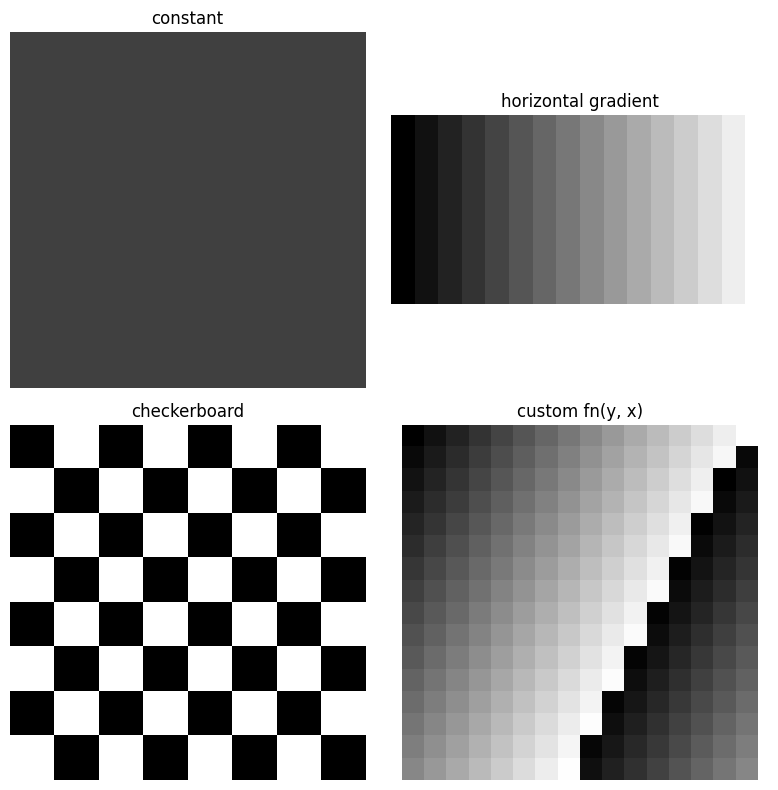

In [44]:
if str(pyref_dir) not in sys.path:
    sys.path.insert(0, str(pyref_dir))

import synth_image

img_constant = synth_image.make_constant(8, 8, 64)
img_hgrad = synth_image.make_horizontal_gradient(16, 8)
img_checker = synth_image.make_checkerboard(16, 16, a=0, b=255, block=2)
img_custom = synth_image.make_from_function(
    16, 16,
    lambda y, x: (x * 17 + y * 9) & 0xFF
)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax, img, title in [
    (axes[0, 0], img_constant, "constant"),
    (axes[0, 1], img_hgrad, "horizontal gradient"),
    (axes[1, 0], img_checker, "checkerboard"),
    (axes[1, 1], img_custom, "custom fn(y, x)"),
]:
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Step 2C — Quick `.mem` round-trip check

Before any compression, verify that your raw image export/import flow is stable.


In [45]:
import image_to_mem

test_img = img_checker.copy()
input_mem = data_dir / "input.mem"
dims_txt = data_dir / "dims.txt"

image_to_mem.save_mem(test_img, input_mem, fmt="hex", include_dims_header=False)
image_to_mem.write_dims_file(test_img, dims_txt)

roundtrip = image_to_mem.load_mem(input_mem, height=test_img.shape[0], width=test_img.shape[1], fmt="hex")

print("Saved input mem:", input_mem)
print("Saved dims txt :", dims_txt)
print("Round-trip OK? :", np.array_equal(test_img, roundtrip))
print("Shape          :", roundtrip.shape)


Saved input mem: /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/input.mem
Saved dims txt : /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/dims.txt
Round-trip OK? : True
Shape          : (16, 16)


## Step 3 — Build `jpegls_regular.py`

This is a **Stage-1 reference encoder**, not yet a full conformance implementation.

### What it does support
- `uint8`
- grayscale
- lossless
- regular mode only
- small-image tests
- bit packing into bytes

### What it intentionally does not do yet
- run mode
- color transforms
- restart markers / file container formatting
- full standard-compliance validation
- hardware-side streaming interfaces

This is exactly the kind of compact reference that is useful before writing HLS.


In [46]:
jpegls_regular_code = r'''from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

import numpy as np


MAXVAL = 255
NEAR = 0
RESET = 64
T1 = 3
T2 = 7
T3 = 21
MIN_C = -128
MAX_C = 127


class BitWriter:
    """
    MSB-first bit packer.

    Internally, bits are appended to a byte accumulator from MSB to LSB.
    The final partial byte is zero-padded on the right when flushed.
    """

    def __init__(self) -> None:
        self._bytes = bytearray()
        self._cur = 0
        self._nbits = 0
        self._written_bits = 0

    def write_bit(self, bit: int) -> None:
        bit = 1 if bit else 0
        self._cur = (self._cur << 1) | bit
        self._nbits += 1
        self._written_bits += 1
        if self._nbits == 8:
            self._bytes.append(self._cur & 0xFF)
            self._cur = 0
            self._nbits = 0

    def write_bits(self, value: int, nbits: int) -> None:
        if nbits < 0:
            raise ValueError("nbits must be nonnegative")
        for i in range(nbits - 1, -1, -1):
            self.write_bit((value >> i) & 1)

    def write_unary(self, q: int) -> None:
        if q < 0:
            raise ValueError("Unary code only supports q >= 0")
        for _ in range(q):
            self.write_bit(1)
        self.write_bit(0)

    def flush(self) -> None:
        if self._nbits:
            self._cur <<= (8 - self._nbits)
            self._bytes.append(self._cur & 0xFF)
            self._cur = 0
            self._nbits = 0

    def to_bytes(self) -> bytes:
        self.flush()
        return bytes(self._bytes)

    def bit_length(self) -> int:
        return self._written_bits


def save_bytes_mem(data: bytes, path: str | Path) -> None:
    txt = "\n".join(f"{b:02X}" for b in data)
    if txt:
        txt += "\n"
    Path(path).write_text(txt, encoding="utf-8")


def get_neighbors(image: np.ndarray, y: int, x: int) -> tuple[int, int, int, int]:
    """
    Return causal JPEG-LS neighbors (A, B, C, D).

      C  B  D
      A  X

    Border convention for this stage-1 model:
      - Missing A/B/C use 0
      - Missing D uses B
    """
    A = int(image[y, x - 1]) if x > 0 else 0
    B = int(image[y - 1, x]) if y > 0 else 0
    C = int(image[y - 1, x - 1]) if (y > 0 and x > 0) else 0
    D = int(image[y - 1, x + 1]) if (y > 0 and x + 1 < image.shape[1]) else B
    return A, B, C, D


def quantize_gradient(g: int) -> int:
    if g <= -T3:
        return -4
    if g <= -T2:
        return -3
    if g <= -T1:
        return -2
    if g < -NEAR:
        return -1
    if g <= NEAR:
        return 0
    if g < T1:
        return 1
    if g < T2:
        return 2
    if g < T3:
        return 3
    return 4


def normalize_context(q1: int, q2: int, q3: int) -> tuple[tuple[int, int, int], int]:
    """
    Sign-normalize the quantized gradient triple.

    Returns:
      ctx_key : normalized context tuple
      sign    : +1 or -1
    """
    if q1 < 0 or (q1 == 0 and q2 < 0) or (q1 == 0 and q2 == 0 and q3 < 0):
        return (-q1, -q2, -q3), -1
    return (q1, q2, q3), 1


def med_predictor(A: int, B: int, C: int) -> int:
    if C >= max(A, B):
        return min(A, B)
    if C <= min(A, B):
        return max(A, B)
    return A + B - C


def golomb_k(Aq: int, Nq: int) -> int:
    k = 0
    while (Nq << k) < Aq:
        k += 1
    return k


def map_error(errval: int) -> int:
    if errval >= 0:
        return 2 * errval
    return -2 * errval - 1


@dataclass
class EncodeResult:
    bitstream_bytes: bytes
    nbits: int
    trace: dict[str, np.ndarray]


class JPEGLSRegularEncoder:
    """
    Small stage-1 reference encoder.

    Scope:
      - uint8 grayscale only
      - lossless only
      - regular mode only
      - educational / bring-up reference
    """

    def __init__(self) -> None:
        self.ctx_to_idx: Dict[Tuple[int, int, int], int] = {}
        self.A: list[int] = []
        self.B: list[int] = []
        self.C: list[int] = []
        self.N: list[int] = []

    def _ctx_index(self, ctx: tuple[int, int, int]) -> int:
        if ctx not in self.ctx_to_idx:
            idx = len(self.ctx_to_idx)
            self.ctx_to_idx[ctx] = idx
            self.A.append(4)
            self.B.append(0)
            self.C.append(0)
            self.N.append(1)
        return self.ctx_to_idx[ctx]

    def encode(self, image: np.ndarray) -> EncodeResult:
        arr = np.asarray(image)
        if arr.dtype != np.uint8 or arr.ndim != 2:
            raise ValueError("image must be a uint8 array with shape (H, W)")

        h, w = arr.shape
        writer = BitWriter()

        pred = np.zeros((h, w), dtype=np.int16)
        err = np.zeros((h, w), dtype=np.int16)
        merr = np.zeros((h, w), dtype=np.uint16)
        kmap = np.zeros((h, w), dtype=np.uint8)
        ctx_id_map = np.zeros((h, w), dtype=np.int16)

        for y in range(h):
            for x in range(w):
                A, B, C, D = get_neighbors(arr, y, x)

                g1 = D - B
                g2 = B - C
                g3 = C - A

                q1 = quantize_gradient(g1)
                q2 = quantize_gradient(g2)
                q3 = quantize_gradient(g3)
                ctx_key, sign = normalize_context(q1, q2, q3)
                q = self._ctx_index(ctx_key)

                Px = med_predictor(A, B, C)
                if sign == 1:
                    Px = Px + self.C[q]
                else:
                    Px = Px - self.C[q]
                Px = min(MAXVAL, max(0, Px))

                cur = int(arr[y, x])
                Errval = cur - Px
                if sign == -1:
                    Errval = -Errval

                k = golomb_k(self.A[q], self.N[q])
                MErrval = map_error(Errval)

                unary_q = MErrval >> k
                rem = MErrval & ((1 << k) - 1) if k > 0 else 0
                writer.write_unary(unary_q)
                if k > 0:
                    writer.write_bits(rem, k)

                pred[y, x] = Px
                err[y, x] = Errval
                merr[y, x] = MErrval
                kmap[y, x] = k
                ctx_id_map[y, x] = q

                self.B[q] += Errval
                self.A[q] += abs(Errval)

                if self.B[q] <= -self.N[q]:
                    self.B[q] += self.N[q]
                    if self.C[q] > MIN_C:
                        self.C[q] -= 1
                    if self.B[q] <= -self.N[q]:
                        self.B[q] = -self.N[q] + 1
                elif self.B[q] > 0:
                    self.B[q] -= self.N[q]
                    if self.C[q] < MAX_C:
                        self.C[q] += 1
                    if self.B[q] > 0:
                        self.B[q] = 0

                if self.N[q] == RESET:
                    self.A[q] >>= 1
                    self.B[q] >>= 1
                    self.N[q] >>= 1

                self.N[q] += 1

        data = writer.to_bytes()
        trace = {
            "pred": pred,
            "err": err,
            "merr": merr,
            "k": kmap,
            "ctx_id": ctx_id_map,
        }
        return EncodeResult(bitstream_bytes=data, nbits=writer.bit_length(), trace=trace)


def encode_image(image: np.ndarray) -> EncodeResult:
    return JPEGLSRegularEncoder().encode(image)'''
(pyref_dir / "jpegls_regular.py").write_text(jpegls_regular_code + "\n", encoding="utf-8")
print("Wrote", pyref_dir / "jpegls_regular.py")


Wrote /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/python_ref/jpegls_regular.py


In [47]:
import jpegls_regular

encoder_result = jpegls_regular.encode_image(test_img)

compressed_mem = data_dir / "compressed.mem"
jpegls_regular.save_bytes_mem(encoder_result.bitstream_bytes, compressed_mem)

print("Compressed bytes :", len(encoder_result.bitstream_bytes))
print("Valid bits       :", encoder_result.nbits)
print("Compressed mem   :", compressed_mem)
print("Trace keys       :", list(encoder_result.trace.keys()))


Compressed bytes : 297
Valid bits       : 2374
Compressed mem   : /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/compressed.mem
Trace keys       : ['pred', 'err', 'merr', 'k', 'ctx_id']


## Inspect the internal trace

For bring-up, the most useful thing is not only the final compressed bytes.

You also want per-pixel traces such as:

- predictor `pred`
- signed residual `err`
- mapped residual `merr`
- chosen Golomb parameter `k`
- context id `ctx_id`

These intermediate arrays are exactly what later RTL/HLS debugging will compare against.


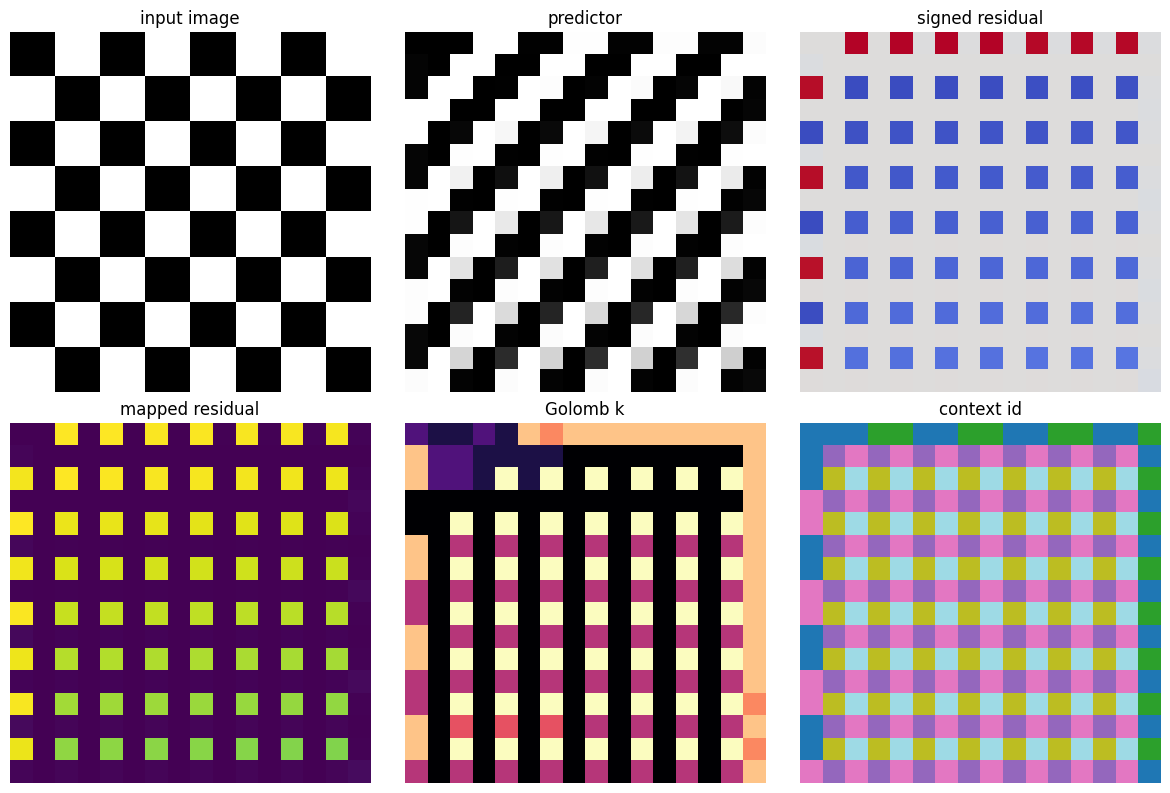

In [48]:
trace = encoder_result.trace

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(test_img, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("input image")
axes[0, 0].axis("off")

axes[0, 1].imshow(trace["pred"], cmap="gray")
axes[0, 1].set_title("predictor")
axes[0, 1].axis("off")

axes[0, 2].imshow(trace["err"], cmap="coolwarm")
axes[0, 2].set_title("signed residual")
axes[0, 2].axis("off")

axes[1, 0].imshow(trace["merr"], cmap="viridis")
axes[1, 0].set_title("mapped residual")
axes[1, 0].axis("off")

axes[1, 1].imshow(trace["k"], cmap="magma")
axes[1, 1].set_title("Golomb k")
axes[1, 1].axis("off")

axes[1, 2].imshow(trace["ctx_id"], cmap="tab20")
axes[1, 2].set_title("context id")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


## Small regression tests

The repo plan emphasizes starting with **tiny synthetic images** and small corner cases.  
So here we run a few very basic sanity tests:

- all zero
- constant image
- horizontal gradient
- checkerboard
- random image


In [49]:
test_images = {
    "all_zero": synth_image.make_constant(8, 8, 0),
    "constant_128": synth_image.make_constant(8, 8, 128),
    "hgrad_8x8": synth_image.make_horizontal_gradient(8, 8),
    "checker_8x8": synth_image.make_checkerboard(8, 8, 0, 255, block=1),
    "random_8x8": synth_image.make_random(8, 8, seed=7),
}

summary = []
for name, img in test_images.items():
    result = jpegls_regular.encode_image(img)
    out_path = data_dir / f"{name}_compressed.mem"
    jpegls_regular.save_bytes_mem(result.bitstream_bytes, out_path)
    summary.append({
        "name": name,
        "shape": img.shape,
        "bytes": len(result.bitstream_bytes),
        "bits": result.nbits,
        "out_path": str(out_path),
    })

summary


[{'name': 'all_zero',
  'shape': (8, 8),
  'bytes': 9,
  'bits': 68,
  'out_path': '/home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/all_zero_compressed.mem'},
 {'name': 'constant_128',
  'shape': (8, 8),
  'bytes': 39,
  'bits': 306,
  'out_path': '/home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/constant_128_compressed.mem'},
 {'name': 'hgrad_8x8',
  'shape': (8, 8),
  'bytes': 21,
  'bits': 167,
  'out_path': '/home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/hgrad_8x8_compressed.mem'},
 {'name': 'checker_8x8',
  'shape': (8, 8),
  'bytes': 186,
  'bits': 1481,
  'out_path': '/home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/checker_8x8_compressed.mem'},
 {'name': 'random_8x8',
  'shape': (8, 8),
  'bytes': 187,
  'bits': 1489,
  'out_path': '/home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/random_8x8_compressed.mem'}]

## Save additional bring-up artifacts

For HLS/RTL debug, it is often useful to save both the input image and the intermediate arrays.


In [50]:
np.save(data_dir / "test_img.npy", test_img)
for key, value in encoder_result.trace.items():
    np.save(data_dir / f"trace_{key}.npy", value)

print("Saved:")
print(" -", data_dir / "test_img.npy")
for key in encoder_result.trace:
    print(" -", data_dir / f"trace_{key}.npy")


Saved:
 - /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/test_img.npy
 - /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/trace_pred.npy
 - /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/trace_err.npy
 - /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/trace_merr.npy
 - /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/trace_k.npy
 - /home/yh6341/9463_04172026_1/hwdesign/labs/jpegls/data/trace_ctx_id.npy


## Optional real-image path

Once your environment has Pillow available, you can switch from synthetic images to real images.

Example workflow:

```python
import image_to_mem
import jpegls_regular

img = image_to_mem.load_image_as_grayscale("my_image.png")
image_to_mem.save_mem(img, "data/my_image.mem")
result = jpegls_regular.encode_image(img)
jpegls_regular.save_bytes_mem(result.bitstream_bytes, "data/my_image_compressed.mem")
```


## What to do next after this notebook

Once this notebook is stable, the next hardware-facing steps are usually:

1. freeze the raw input `.mem` format
2. freeze the compressed byte packing rule
3. freeze border handling for `A/B/C/D`
4. freeze the Python trace names and shapes
5. build an HLS/RTL module that reproduces the same:
   - predictor
   - residual
   - mapped residual
   - Golomb parameter selection
   - bit packing

That way your HLS bring-up can compare against:
- `input.mem`
- `compressed.mem`
- `trace_pred.npy`
- `trace_err.npy`
- `trace_merr.npy`
- `trace_k.npy`
- `trace_ctx_id.npy`

This is the cleanest way to do incremental debug.
